# LoRa (Low Rank adaptation) fine-tuning

The LoRa method allows us to fine-tune models by using less parameters and then using less memory and GPU.   

## **But how ?** ##

Let's take the example of BERT Base . BERT Base is a language model that only uses encoder . He uses 6 layers of encoders .  

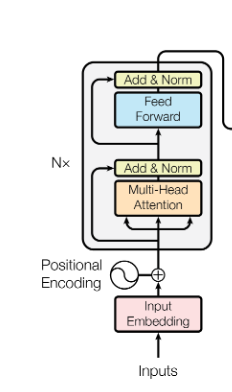



BERT-Base has **110 millions trainable parameters**. Therefore we need to save the gradient of every parameter so we finally have at least **2 x 110 millions** parameters to save. 

# 1)Method 1: PEFT 

1) We use a different version of the **Encoder** architecture coming from the **"Parameter efficient Transfer Learning for NLP** paper 
2) In this architecture we added a new Layer : **Adapter Layer** , that allows the **Parameter efficient fine-tuning (PEFT)** method 

(Video link : https://www.youtube.com/watch?v=HcVtpLAGMXo&t=60s)

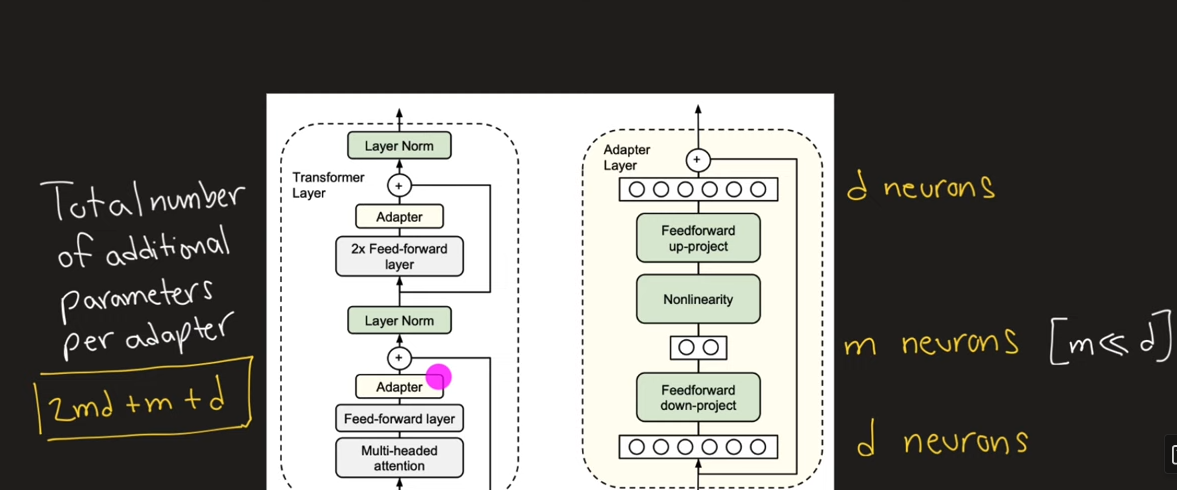

During the training we only train the adapter's weights , and the others wieght we freeze them .

Let's take a quick example : 
- Let's considere a matrix with the following size (we skip the batch dimension) :  
$$ M_{input} = (seqLen , 1024)$$
- Then we put this matrix to the first adapter :  
$$ Output =M_{input} +\sigma(M_{input} * W_{Down}^T + b) *  W_{up}^T$$
With 
   $$W_{Down}^T = (1024,64)$$
   $$ W_{up}^T = (64,1024) $$

For this adapter we will train **99K parameters**
$$ 2 *16 * 1024 * 64 * 2 + 1024 + 64 = 4229120 $$

We have two adapter layers so finally we will train : **4.2M** parameters instead of **345M** for **Bert Large**  
It is **1.21%** of the total number of parameter


# 2) Methode 2 : LoRa 

LoRa method does not add a new layer to the architecture but instead we add to every learnable matrix **(for example the matrices of the multi-head attention W_Q, W_K, W_V)** and then we add to them another matrix called $\Delta W$. This matrix contains the **trainable weights**.

## But what contains $\Delta W$ ?

$$
\Delta W = B A
$$

With: 

- $B \in \mathbb{R}^{r \times d_{in}}$ : projects the input vector into a low-rank latent space of dimension $r$.  
- $A \in \mathbb{R}^{d_{out} \times r}$ : projects back from the low-rank latent space to the original output dimension.  
- $r$ is a small number (e.g., 16, 32, 64) much smaller than $d_{in}$ and $d_{out}$, which makes the fine-tuning **lightweight**.

### Dimensions

| Matrix | Shape |
|--------|-------|
| Original $W$ | $[d_{out}, d_{in}]$ |
| $B$ | $[r, d_{in}]$ |
| $A$ | $[d_{out}, r]$ |
| $\Delta W = B A$ | $[d_{out}, d_{in}]$ |

### Intuition

- $B$ compresses the input features into a smaller latent space.  
- $A$ expands it back to the original output space.  
- Each element of $\Delta W$ is a **linear combination of $r$ latent components**, creating a low-rank correction applied to $W$ during the forward pass.

### Forward pass

For an input $x$:

$$
\text{output} = x W^T + x \Delta W^T = x W^T + x (A B)^T
$$

- $x W^T$ → original output (weights frozen)  
- $x \Delta W^T$ → trainable correction applied to the output  
- The output keeps the **same dimension** as before.

## Number of trainable parameters compared to BERT-large

- **BERT-large** total parameters: ~335M  
- Typical LoRA setup (r = 16) applied to all attention matrices (`W_Q`, `W_K`, `W_V`, `W_O`) :  

$$
\text{trainable params} \approx 4 \times (d_{model} \times r + r \times d_{model}) \times n_\text{layers}
$$

- For BERT-large:  
  - `d_model = 1024`  
  - `r = 16`  
  - `n_layers = 24`  
- Approximate trainable parameters:
$$
4 \times (1024 \times 16 + 16 \times 1024) \times 24 = 4 \times 32768 \times 24 \approx 3\,145\,728
$$


So about **~3.1M trainable parameters**, which is **less than 1%** of the full 335M parameters.  

- Huge memory and computation saving while still adapting the model effectively to new tasks.


# 3) Comparisons:

We can compare adapters and LoRA in terms of trainable parameters, efficiency, and memory footprint.  
Below is a summary based on the official paper.

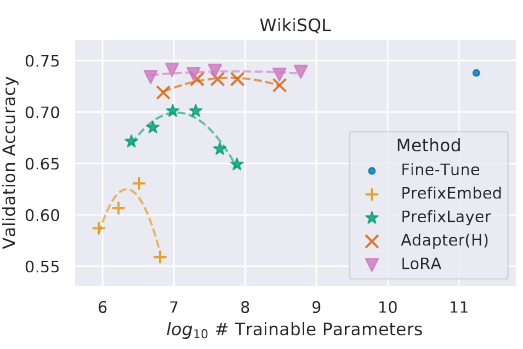

## Conclusion :
Use LoRa for fine-tuning tasks !!!


## Let's code now that we have the theoery !!!!

In [64]:
from transformers import (AutoTokenizer,AutoModelForCausalLM,TrainingArguments, BitsAndBytesConfig)
from datasets import load_dataset
from trl import SFTTrainer , SFTConfig
from peft import get_peft_model,LoraConfig
import numpy as np 
import torch 

In [5]:
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
dataset_name = "mamachang/medical-reasoning"

1) Let's import our model but let's quantized it before with NF4 method seen before !

In [9]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

Now we can import our model without crashing our laptop this time ;)

In [22]:
model = AutoModelForCausalLM.from_pretrained(model_name,quantization_config = bnb_config)
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

# Let's create our LoRa configuration that we will use use to fine-tune our model 

In [14]:
lora_config = LoraConfig(
    task_type="CAUSAL_LM",
    r= 64,
    lora_alpha=16,
    target_modules=["q_proj",'v_proj'],
    lora_dropout=0.01,
)

model = get_peft_model(model,lora_config)


In [15]:
dataset = load_dataset(dataset_name ,split="train")

The dataset used has some  tokens , so let's add them to our model vocabulary to avoir the tokenizer chunking them .  

**Example**:  
We want the tokenizer to understand the entire token: *<answer>* and not to split it into 3 tokens for example :  
**["<an","swe","r>"]**

In [44]:
tokens =[
    "</answer>'",
    "<answer",
    "<analysis>",
    "</analysis>"
]

num_tokens_added = tokenizer.add_tokens(tokens)
print(f"We added {num_tokens_added} tokens !")


We added 4 tokens !


# Important : We need to reshape our embeddings because the old one did not have 4 rows representing the embeddings of each token .

In [46]:
model.resize_token_embeddings(len(tokenizer))

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Embedding(32004, 2048)

If you execute the code you will notice the following output :`Embedding(32004, 2048)` what shows us that now we have the embedding of these new tokens !

# Let's prepare ou dataset

Let's see what our dataset look-like

In [52]:
print(dataset['instruction'])

Column(['Please answer with one of the option in the bracket. Write reasoning in between <analysis></analysis>. Write answer in between <answer></answer>.', 'Please answer with one of the option in the bracket. Write reasoning in between <analysis></analysis>. Write answer in between <answer></answer>.', 'Please answer with one of the option in the bracket. Write reasoning in between <analysis></analysis>. Write answer in between <answer></answer>.', 'Please answer with one of the option in the bracket. Write reasoning in between <analysis></analysis>. Write answer in between <answer></answer>.', 'Please answer with one of the option in the bracket. Write reasoning in between <analysis></analysis>. Write answer in between <answer></answer>.'])


Here is the output :  

Dataset({
    features: ['input', 'instruction', 'output'],
    num_rows: 3702
})  

We have 3 columns , the input , the instruction and the output.

I will preprocess it to obtain something like this :

`<|system|>Instruction</s>  
<|user|>Input </s>  
<|assistant|> Output</s>`  

In [54]:
def prepare_ds(example):
    full_prompt = (
            f"<|system|> {example['instruction']}</s>"
            f"<|user|> {example['input']}</s>"
            f"<|assistant|> {example['output']}</s>" 
        )
    return {"text": full_prompt}

dataset = dataset.map(prepare_ds).remove_columns(["instruction",'input','output'])

Map:   0%|          | 0/3702 [00:00<?, ? examples/s]

Let's finally create ou trainer with the **TrainingArguments** that we want !

In [ ]:
training_args= TrainingArguments(
    output_dir="./results",

)

sft_config = SFTConfig(
    output_dir="./results",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=3,
    bf16=True,
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,
    max_length=775
    
)

trainer = SFTTrainer(
    model,
    args=training_args,
    train_dataset= dataset,
    SFTConfig= sft_config
)

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'max_length'